# PHASE2 Facial Emotion Training Notebook Documentation

## Purpose
This notebook trains and evaluates the facial emotion model (ViT-based) for the MMER system using FER2013-style inputs and records export-ready artifacts.

## Scope
- Environment setup and dependency installation
- Dataset loading, preprocessing, and dataloader creation
- Model initialization, training loop, and validation metrics
- Artifact export for backend inference integration

## Expected Inputs
- Dataset archive available in Google Drive (`fer2013.zip`) or equivalent local path
- GPU runtime preferred for training performance

## Expected Outputs
- Trained model checkpoint(s)
- Evaluation metrics (accuracy/precision/recall/F1)
- Supporting plots and optional deployment-ready files

## Reproducibility Notes
- Run cells in section order from top to bottom
- Keep path variables centralized in setup cells
- Update random seeds and hyperparameters explicitly before training reruns

## Maintenance Notes
- Preserve section headers and keep code changes localized to the relevant section
- Add markdown notes when introducing new preprocessing or augmentation logic
- Keep exported artifact names stable when possible to avoid backend integration drift

## 1. GPU Setup & Environment

In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Define your paths
# Note: Ensure 'fer2013.zip' is in your 'MyDrive' folder
zip_source = '/content/drive/MyDrive/fer2013.zip'
destination = '/content/data/raw/'

# 3. Create the destination directory
print(f"Creating directory: {destination}")
!mkdir -p {destination}

# 4. Check for the Zip file and Unzip (The Fast Method)
if os.path.exists(zip_source):
    print("Found 'fer2013.zip'. Unzipping now... (This is fast)")

    # -q means 'quiet' (hides the long list of file names)
    # -d specifies the destination folder
    !unzip -q {zip_source} -d {destination}

    print("Success! Dataset unzipped.")

else:
    # Fallback or Error message
    print(f"⚠️ Could not find: {zip_source}")
    print("Please make sure you have zipped your 'fer2013' folder and uploaded it to Drive.")
    print("If you really want to copy the unzipped folder (slow), uncomment the line below:")
    # !cp -r /content/drive/MyDrive/fer2013 /content/data/raw/

# 5. Verify the data
print("\nVerifying data...")
# List the contents to see if the folder structure is correct
!ls -lh {destination}

# Count how many files are inside (to ensure everything transferred)
# Adjust the path below if your zip file extracts into a subfolder like 'fer2013/train'
print("Counting files (this may take a moment)...")
!find {destination} -type f | wc -l

Mounted at /content/drive
Creating directory: /content/data/raw/
Found 'fer2013.zip'. Unzipping now... (This is fast)
Success! Dataset unzipped.

Verifying data...
total 8.0K
drwxr-xr-x 4 root root 4.0K Nov 22 13:32 fer2013
drwxr-xr-x 3 root root 4.0K Dec 17 06:25 __MACOSX
Counting files (this may take a moment)...
71791


In [2]:
# Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Enable TF32 for A100
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("✓ TF32 optimizations enabled")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.47 GB
✓ TF32 optimizations enabled


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [3]:
# Install required packages
!pip install -q transformers timm gradio opencv-python librosa soundfile scikit-learn tqdm 2>&1 | tail -5
print("✓ Packages installed")

✓ Packages installed


In [4]:
# Imports
import os
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import gradio as gr
import json
from datetime import datetime

print("✓ All imports successful")

✓ All imports successful


## 2. Dataset Creation & Loading

In [5]:
# Load real FER2013 dataset
def load_fer2013(root_dir='/content/data/raw/fer2013'):
    """Load existing FER2013 dataset from disk"""
    emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

    print(f"Loading FER2013 dataset from: {root_dir}\n")

    for split in ['train', 'test']:
        split_dir = Path(root_dir) / split
        print(f"{split.upper()} SET:")
        total_images = 0

        for emotion in emotions:
            emotion_dir = split_dir / emotion
            if emotion_dir.exists():
                img_count = len(list(emotion_dir.glob('*.jpg')))
                print(f"  {emotion}: {img_count} images")
                total_images += img_count
            else:
                print(f"  {emotion}: 0 images (folder not found)")

        print(f"  Total: {total_images} images\n")

    print(f"✓ FER2013 dataset loaded successfully")
    return root_dir

# Load dataset
fer2013_root = load_fer2013()

Loading FER2013 dataset from: /content/data/raw/fer2013

TRAIN SET:
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images
  Total: 28709 images

TEST SET:
  angry: 958 images
  disgust: 111 images
  fear: 1024 images
  happy: 1774 images
  neutral: 1233 images
  sad: 1247 images
  surprise: 831 images
  Total: 7178 images

✓ FER2013 dataset loaded successfully


In [6]:
# Simple FER2013 Dataset class
class FER2013Dataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform
        self.emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
        self.emotion2idx = {e: i for i, e in enumerate(self.emotions)}

        self.samples = []
        self._load_samples()

    def _load_samples(self):
        split_dir = self.root_dir / self.split
        for emotion in self.emotions:
            emotion_dir = split_dir / emotion
            if emotion_dir.exists():
                for img_file in emotion_dir.glob('*.jpg'):
                    self.samples.append((str(img_file), self.emotion2idx[emotion]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            img = np.zeros((48, 48), dtype=np.uint8)

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        return img, torch.tensor(label, dtype=torch.long)

print("✓ Dataset class defined")

✓ Dataset class defined


In [7]:
# Create dataloaders
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

train_dataset = FER2013Dataset(fer2013_root, split='train', transform=transform_train)
test_dataset = FER2013Dataset(fer2013_root, split='test', transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")

✓ Train samples: 28709
✓ Test samples: 7178


## 3. ResNet-18 Baseline Training

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc, np.array(all_preds), np.array(all_labels)

print("✓ Training functions defined")

✓ Training functions defined


In [9]:
# Train ResNet-18 baseline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 15
learning_rate = 0.001

# Initialize ResNet-18
resnet_model = models.resnet18(pretrained=True)
resnet_model.fc = nn.Linear(512, 7)  # 7 emotions
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)

print("\n=== ResNet-18 Baseline Training ===")
for epoch in range(num_epochs):
    train_loss = train_epoch(resnet_model, train_loader, optimizer, criterion, device)
    test_acc, _, _ = eval_epoch(resnet_model, test_loader, device)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Test Acc: {test_acc:.4f}")

print("\n✓ ResNet-18 baseline training complete")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]



=== ResNet-18 Baseline Training ===


Evaluating: 100%|██████████| 225/225 [00:10<00:00, 21.13it/s]


Epoch 1/15 | Loss: 1.2553 | Test Acc: 0.5659


...

Epoch 13/15 | Loss: 0.2472 | Test Acc: 0.6467


Evaluating: 100%|██████████| 225/225 [00:10<00:00, 21.29it/s]


Epoch 14/15 | Loss: 0.2248 | Test Acc: 0.6491


Evaluating: 100%|██████████| 225/225 [00:10<00:00, 21.21it/s]

Epoch 15/15 | Loss: 0.1785 | Test Acc: 0.6319

✓ ResNet-18 baseline training complete


## 4. Vision Transformer Training

In [10]:
# Load Vision Transformer
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=7,
    ignore_mismatched_sizes=True
)
vit_model = vit_model.to(device)

# Optimizer
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=5e-5)
vit_criterion = nn.CrossEntropyLoss()

print("✓ Vision Transformer model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Vision Transformer model loaded


In [11]:
# Train Vision Transformer
num_vit_epochs = 15

print("\n=== Vision Transformer Training ===")
for epoch in range(num_vit_epochs):
    vit_model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader, desc=f"ViT Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        vit_optimizer.zero_grad()
        outputs = vit_model(pixel_values=images)
        loss = vit_criterion(outputs.logits, labels)
        loss.backward()
        vit_optimizer.step()
        total_loss += loss.item()

    # Evaluate
    vit_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = vit_model(pixel_values=images)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    test_acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{num_vit_epochs} | Loss: {total_loss/len(train_loader):.4f} | Test Acc: {test_acc:.4f}")

print("\n✓ Vision Transformer training complete")


=== Vision Transformer Training ===


ViT Epoch 1: 100%|██████████| 898/898 [01:38<00:00,  9.12it/s]


Epoch 1/15 | Loss: 1.0788 | Test Acc: 0.6478


ViT Epoch 2: 100%|██████████| 898/898 [01:37<00:00,  9.23it/s]


Epoch 2/15 | Loss: 0.7928 | Test Acc: 0.6811


...

Epoch 13/15 | Loss: 0.0654 | Test Acc: 0.7045


ViT Epoch 14: 100%|██████████| 898/898 [01:37<00:00,  9.18it/s]


Epoch 14/15 | Loss: 0.0606 | Test Acc: 0.7052


ViT Epoch 15: 100%|██████████| 898/898 [01:39<00:00,  8.99it/s]


Epoch 15/15 | Loss: 0.0792 | Test Acc: 0.7129

✓ Vision Transformer training complete


## 5. Model Evaluation

In [12]:
# Final evaluation
vit_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = vit_model(pixel_values=images)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n=== Vision Transformer Performance ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


=== Vision Transformer Performance ===
Accuracy:  0.7129
Precision: 0.7185
Recall:    0.7129
F1-Score:  0.7111


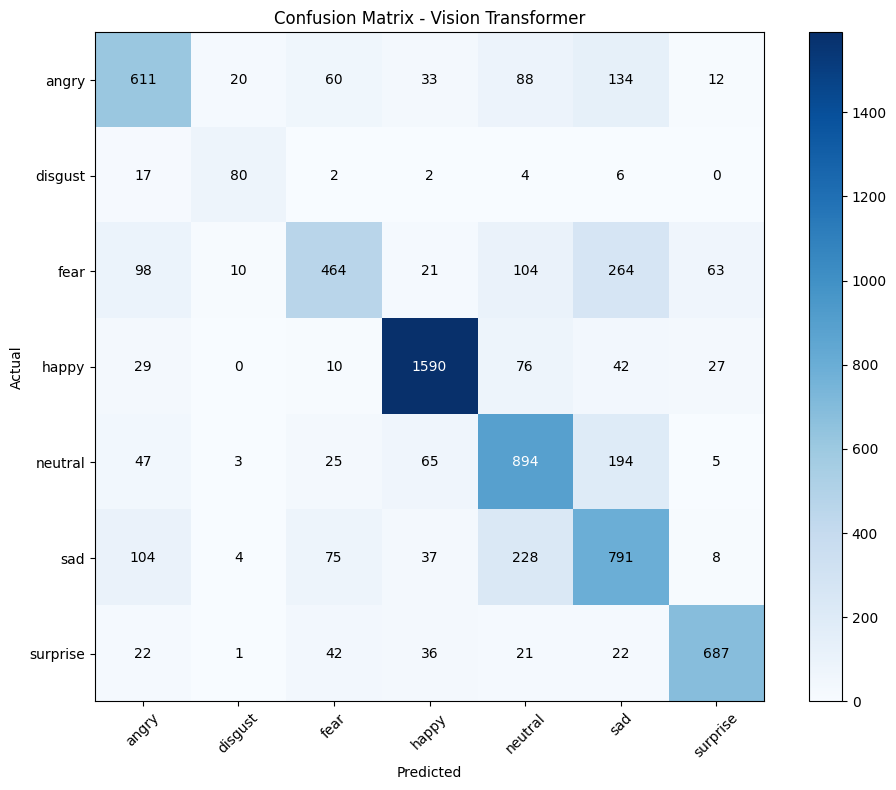

✓ Confusion matrix displayed


In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix - Vision Transformer')
plt.colorbar()
plt.xticks(range(7), emotions, rotation=45)
plt.yticks(range(7), emotions)
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Add text annotations
for i in range(7):
    for j in range(7):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

print("✓ Confusion matrix displayed")

## 6. Save Model

In [14]:
# Save model
model_dir = Path('/content/models/phase2')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'vit_emotion_model.pt'
torch.save({
    'model_state_dict': vit_model.state_dict(),
    'accuracy': accuracy,
    'timestamp': datetime.now().isoformat()
}, model_path)

print(f"✓ Model saved to {model_path}")

✓ Model saved to /content/models/phase2/vit_emotion_model.pt


## 7. Interactive Gradio Demo

In [15]:
def predict_emotion(image):
    """Predict emotion from image"""
    if image is None:
        return {emotion: 0 for emotion in emotions}

    # Prepare image
    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Transform
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img_tensor = transform_test(img).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = vit_model(pixel_values=img_tensor)
        logits = outputs.logits.cpu().numpy()[0]
        probs = np.exp(logits) / np.sum(np.exp(logits))

    # Return probabilities
    return {emotion: float(prob) for emotion, prob in zip(emotions, probs)}

# Create interface
demo = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(type='pil', label='Upload Facial Image'),
    outputs=gr.Label(label='Emotion Probabilities', num_top_classes=7),
    title='Facial Emotion Recognition (Phase 2)',
    description='Upload a facial image to predict emotion using Vision Transformer'
)

print("✓ Gradio demo ready")

✓ Gradio demo ready


In [16]:
# Launch demo
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50a10567d7193088d1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
from google.colab import files
files.download('/content/models/phase2/vit_emotion_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>